# 转置卷积

卷积神经网络层，例如卷积层和汇聚层，通常会减少下采样输入图像的空间维度（高和宽）。 然而如果输入和输出图像的空间维度相同，在以像素级分类的语义分割中将会很方便。

为了实现这一点，尤其是在空间维度被卷积神经网络层缩小后，我们可以使用另一种类型的卷积神经网络层，它可以**增加上采样中间层特征图的空间维度**。

转置卷积只是以一个不损失信息的方式变换feature图，把它拉大，无法还原到卷积之前

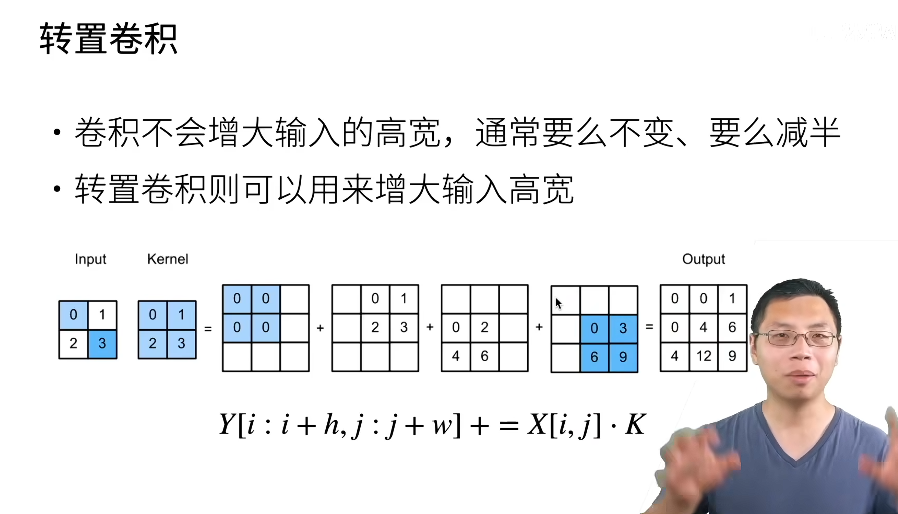

类似卷积反过程，每个输入和核相乘得到一个矩阵，把所有矩阵按在矩阵里的位置相加

卷积之后的矩阵的每个元素有一个感受视野，反卷积希望通过这个元素还原感受视野里面的内容。

由于卷积后的元素的感受视野有相交的情况，所以反卷积中也出现了结果中有些元素的值来源于卷积结果的一个或多个元素的现象，理论上通过反卷积，我们可以通过将特征图反卷积还原到原图大小从而获取到我们的卷积核在原图中提取的是什么信息。

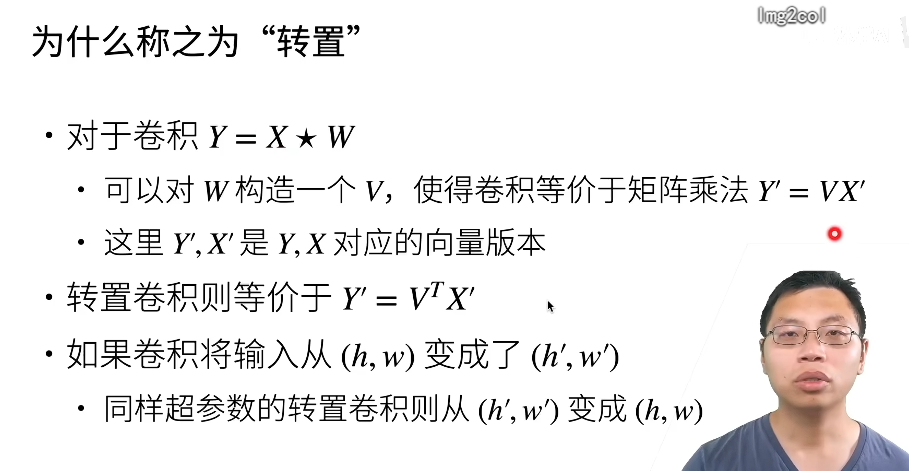

回顾：因为矩阵乘法计算更快，一般使用im2col将输入特征图（图像）重新排列成一个二维矩阵后再计算

## 代码

In [3]:
import torch
from torch import nn
from d2l import torch as d2l

转置卷积

In [4]:
def trans_conv(X, K):
    h, w = K.shape
    # 初始化结果矩阵
    Y = torch.zeros((X.shape[0] + h - 1, X.shape[1] + w - 1))
    # 按输入计算
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            # 结果矩阵对应位置加上相乘结果
            Y[i: i + h, j: j + w] += X[i, j] * K
    return Y

In [5]:
X = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
trans_conv(X, K)

tensor([[ 0.,  0.,  1.],
        [ 0.,  4.,  6.],
        [ 4., 12.,  9.]])

使用高级API获得相同的结果

In [6]:
X, K = X.reshape(1, 1, 2, 2), K.reshape(1, 1, 2, 2)
tconv = nn.ConvTranspose2d(1, 1, kernel_size=2, bias=False)
tconv.weight.data = K
tconv(X)

tensor([[[[ 0.,  0.,  1.],
          [ 0.,  4.,  6.],
          [ 4., 12.,  9.]]]], grad_fn=<ConvolutionBackward0>)

填充、步幅和多通道

In [7]:
tconv = nn.ConvTranspose2d(1, 1, kernel_size=2, padding=1, bias=False)
tconv.weight.data = K
tconv(X)

tensor([[[[4.]]]], grad_fn=<ConvolutionBackward0>)

In [8]:
tconv = nn.ConvTranspose2d(1, 1, kernel_size=2, stride=2, bias=False)
tconv.weight.data = K
tconv(X)

tensor([[[[0., 0., 0., 1.],
          [0., 0., 2., 3.],
          [0., 2., 0., 3.],
          [4., 6., 6., 9.]]]], grad_fn=<ConvolutionBackward0>)

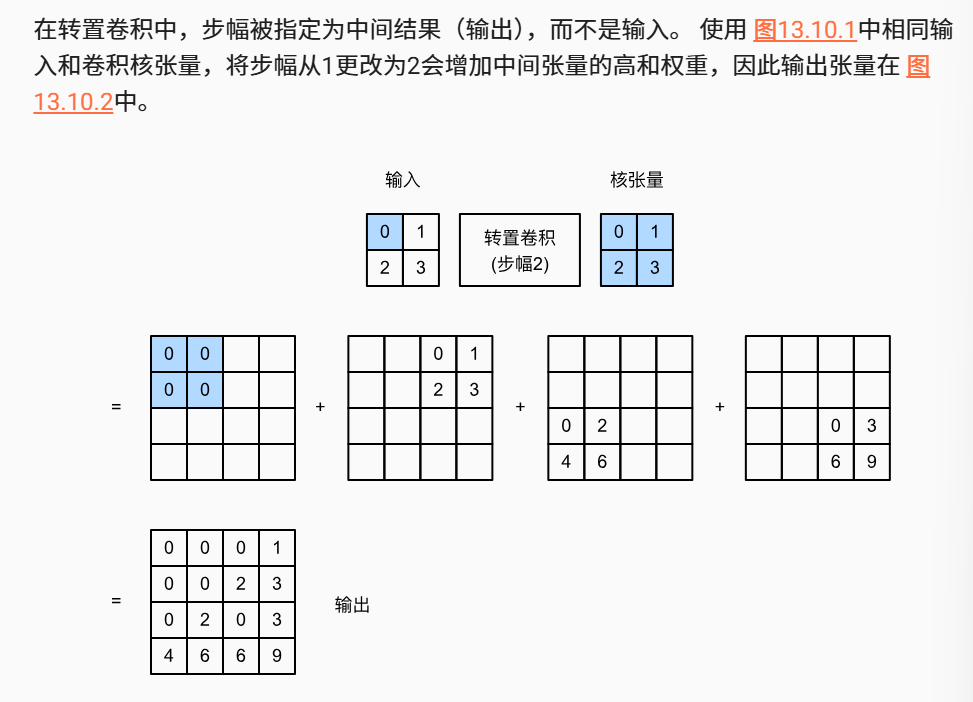

In [15]:
X = torch.rand(size=(1, 10, 16, 16))
conv = nn.Conv2d(10, 20, kernel_size=5, padding=2, stride=3)
tconv = nn.ConvTranspose2d(20, 10, kernel_size=5, padding=2, stride=3)
tconv(conv(X)).shape == X.shape

True

转置不是可逆，所以值不是一样的，是形状上的转置

与矩阵变换的联系

In [ ]:
X = torch.arange(9.0).reshape(3, 3)
K = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
Y = d2l.corr2d(X, K)   # 算出卷积
Y

tensor([[27., 37.],
        [57., 67.]])

将卷积核K重写为包含大量0的稀疏权重矩阵W

In [11]:
def kernel2matrix(K):
    k, W = torch.zeros(5), torch.zeros((4, 9))
    k[:2], k[3:5] = K[0, :], K[1, :]
    W[0, :5], W[1, 1:6], W[2, 3:8], W[3, 4:] = k, k, k, k
    return W

W = kernel2matrix(K)
W

tensor([[1., 2., 0., 3., 4., 0., 0., 0., 0.],
        [0., 1., 2., 0., 3., 4., 0., 0., 0.],
        [0., 0., 0., 1., 2., 0., 3., 4., 0.],
        [0., 0., 0., 0., 1., 2., 0., 3., 4.]])

使用矩阵乘法实现了卷积

In [12]:
Y == torch.matmul(W, X.reshape(-1)).reshape(2, 2)

tensor([[True, True],
        [True, True]])

这里只是说明转置卷积等效于矩阵乘法，并不是指它们互逆

In [13]:
Z = trans_conv(Y, K)
Z == torch.matmul(W.T, Y.reshape(-1)).reshape(3, 3)

tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])